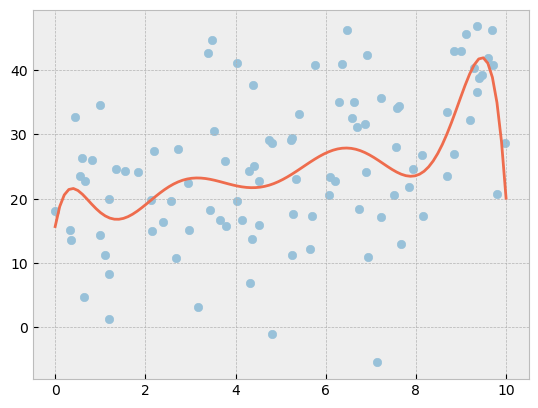

In [98]:
import numpy as np

plt.style.use('bmh') 
colors = ["#3d5a80","#98c1d9","#e0fbfc","#ee6c4d","#293241"]

max_polynomial = 10

x = np.random.uniform(0, 10, 100)
X = np.array([x**n for n in range(0,max_polynomial)]).T
noise = np.random.normal(10, 10, 100)
y = 2*x + 5 + noise




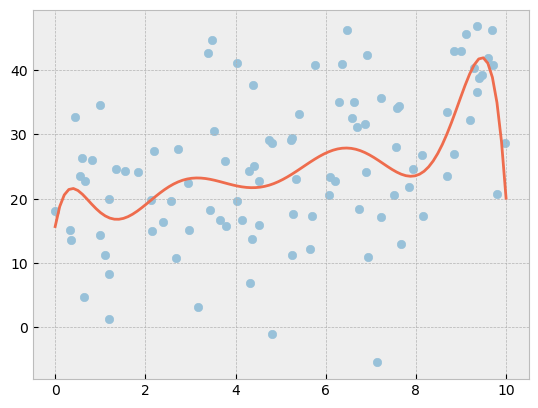

In [102]:
# Linear regression y=wX+b, normal equation (X^TX)(X^Ty)
xTx = np.dot(np.transpose(X), X)
xTy = np.dot(np.transpose(X), y)
weights = np.dot(np.linalg.inv(xTx),xTy)

# # Generate line
x_line = np.linspace(0, 10, 100)
y_line = weights[0];
for n in range(1, max_polynomial):
    y_line += x_line**n * weights[n]


# # Plot
plt.scatter(x, y, color=colors[1], alpha=1, label='$y = 2x + 5 + \\text{noise}$')
plt.plot(x_line, y_line, color=colors[3], linewidth=2)

In [99]:
weights

array([ 1.56753280e+01,  3.85287994e+01, -8.31689769e+01,  7.06624600e+01,
       -3.00112062e+01,  7.08036835e+00, -9.56975847e-01,  7.20111167e-02,
       -2.68660948e-03,  3.48744165e-05])

L2 norm of weights:  3.63188846267968
[ 2.30967989e+00  1.72792277e+00  1.56380518e+00  1.26149762e+00
  3.68017212e-01 -7.85619386e-01  2.80765536e-01 -4.40249214e-02
  3.26573485e-03 -9.36270593e-05]


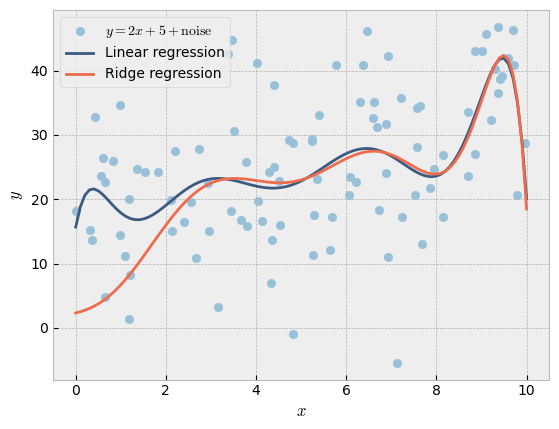

In [142]:
lamb=100

# Ridge regression y=wX+b, adding regularizer w^Tw to the loss function. normal equation (X^TX + λI)^-1(X^Ty)
xTxli = np.dot(np.transpose(X), X) + np.identity(max_polynomial) * lamb
xTy = np.dot(np.transpose(X), y)
weights_ridge = np.dot(np.linalg.inv(xTxli),xTy)

print("L2 norm of weights: ", np.linalg.norm(weights_ridge, 2))
print(weights_ridge)

# # Generate line
x_line_ridge = np.linspace(0, 10, 100)
y_line_ridge = weights_ridge[0];
for n in range(1, max_polynomial):
    y_line_ridge += x_line_ridge**n * weights_ridge[n]
    
plt.scatter(x, y, color=colors[1], alpha=1, label='$y = 2x + 5 + \\text{noise}$')
plt.plot(x_line, y_line, color=colors[0], linewidth=2, label='Linear regression')
plt.plot(x_line_ridge, y_line_ridge, color=colors[3], linewidth=2, label=f'Ridge regression')


plt.xlabel('$x$')
plt.ylabel('$y$')
plt.grid(True)
plt.legend()